# Traffic Flow Prediction and Analysis

This notebook predicts traffic at different junctions using Linear Regression.

Additional analysis includes:
- Traffic heatmaps
- Junction comparison graphs
- Model evaluation metrics

These predictions can later be used in routing algorithms (like Dijkstra) to compute least-congested routes.

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [4]:
df = pd.read_csv('traffic.csv')
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


## 3. Preprocessing

In [5]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month
df['weekday'] = df['DateTime'].dt.weekday

df.head()

,DateTime,Junction,Vehicles,ID,hour,day,month,weekday
0,2015-11-01 00:00:00,1,15,20151101001,0,1,11,6
1,2015-11-01 01:00:00,1,13,20151101011,1,1,11,6
2,2015-11-01 02:00:00,1,10,20151101021,2,1,11,6
3,2015-11-01 03:00:00,1,7,20151101031,3,1,11,6
4,2015-11-01 04:00:00,1,9,20151101041,4,1,11,6


## 4. Traffic Distribution by Hour

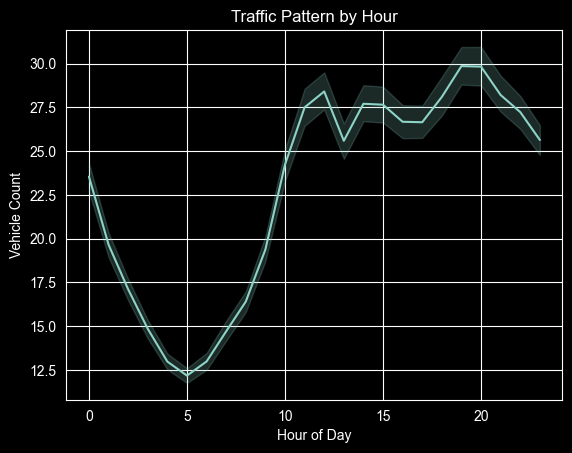

In [6]:
sns.lineplot(data=df, x='hour', y='Vehicles')
plt.title('Traffic Pattern by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Vehicle Count')
plt.show()

## 5. Junction Comparison

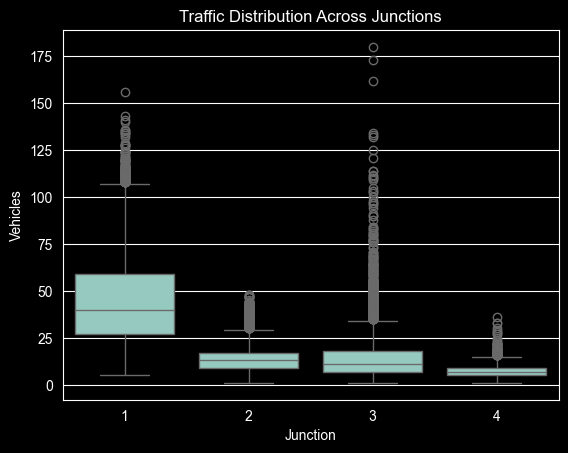

In [7]:
sns.boxplot(x='Junction', y='Vehicles', data=df)
plt.title('Traffic Distribution Across Junctions')
plt.xlabel('Junction')
plt.ylabel('Vehicles')
plt.show()

## 6. Average Traffic Per Junction

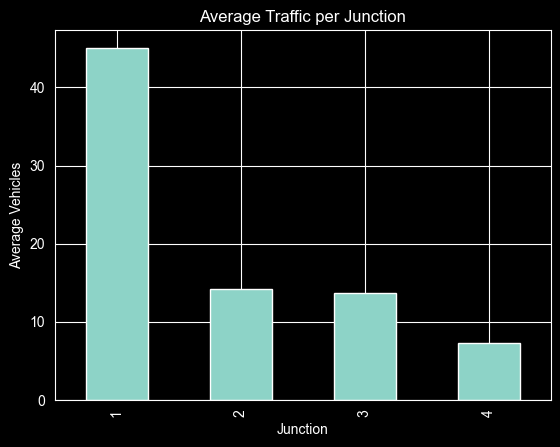

In [8]:
junction_avg = df.groupby('Junction')['Vehicles'].mean()
junction_avg.plot(kind='bar')
plt.title('Average Traffic per Junction')
plt.xlabel('Junction')
plt.ylabel('Average Vehicles')
plt.show()

## 7. Traffic Heatmap (Hour vs Junction)

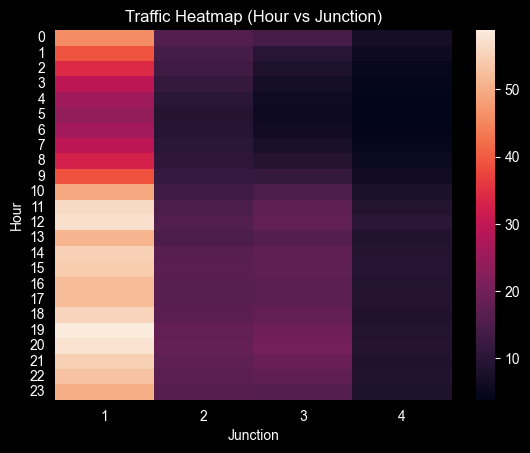

In [9]:
pivot = df.pivot_table(values='Vehicles', index='hour', columns='Junction', aggfunc='mean')

sns.heatmap(pivot, annot=False)
plt.title('Traffic Heatmap (Hour vs Junction)')
plt.xlabel('Junction')
plt.ylabel('Hour')
plt.show()

## 8. Feature Selection

In [10]:
X = df[['Junction','hour','day','month','weekday']]
y = df['Vehicles']

## 9. Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 10. Train Linear Regression Model

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 11. Prediction

In [13]:
y_pred = model.predict(X_test)

## 12. Model Evaluation

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 11.111573436200333
RMSE: 14.919815120121866
R2 Score: 0.45380281764282904


## 13. Actual vs Predicted Traffic

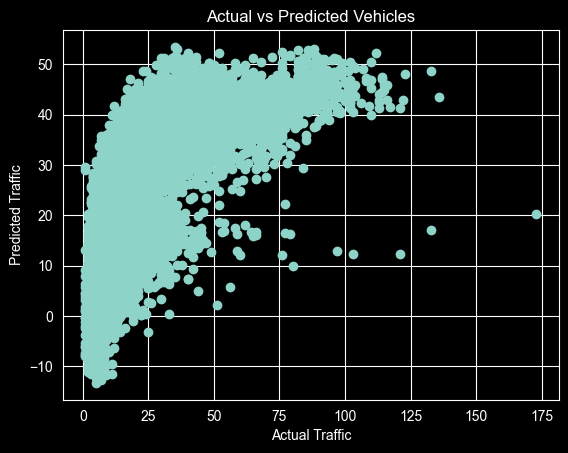

In [15]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Traffic')
plt.ylabel('Predicted Traffic')
plt.title('Actual vs Predicted Vehicles')
plt.show()